<a href="https://colab.research.google.com/github/rsouparnika/DL-25-26/blob/main/Program5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0101 - val_loss: 0.0028
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0024 - val_loss: 0.0016
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0016 - val_loss: 0.0013
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.6735e-04 - val_loss: 8.1684e-04
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.5704e-04 - val_loss: 6.7027e-04
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1699e-04 - val_loss: 5.6104e-04
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.8808e-04 - val_loss: 4.6243e-04
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.1823e-04 - val_loss: 3.9324e-04
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.4943e-04 - val_loss: 3.3498e-04
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.9572e-04 - val_loss: 3.1009e-04
Epoch 12/50
50/50

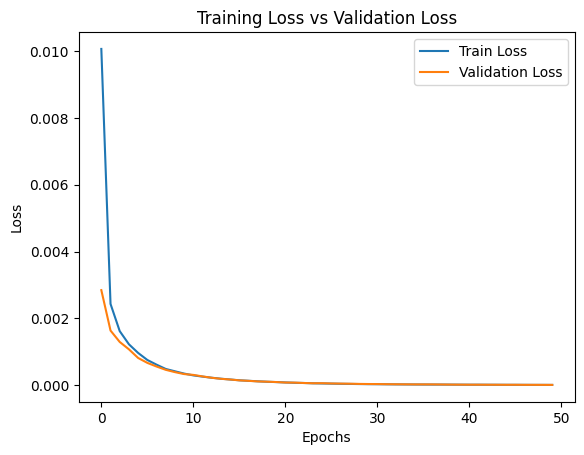

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import matplotlib.pyplot as plt

def generate_sequence(seq_length=5, num_samples=1000):
    X, y = [], []
    for _ in range(num_samples):
        seq = np.random.rand(seq_length)
        X.append(seq)
        y.append(seq[-1] + 0.1) # Predict next value with a small shift
    return np.array(X), np.array(y)

seq_length = 5
X, y = generate_sequence(seq_length)
X = X.reshape((X.shape[0], seq_length, 1))
split = int(0.8 * len(X))

X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

model = Sequential([
SimpleRNN(10, activation='relu', input_shape=(seq_length, 1)), # RNN Layer
Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.summary()

history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

test_loss = model.evaluate(X_test, y_test)

print(f"Test Loss: {test_loss}")

sample_input = np.array([0.1, 0.2, 0.3, 0.4, 0.5]).reshape(1, seq_length, 1)
predicted_value = model.predict(sample_input)
print(f"Predicted next value: {predicted_value}")

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss vs Validation Loss')
plt.show()